# Customer Churn Prediction: The Retention Playbook

## Section 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2: Load Dataset
Load the Telco Customer Churn CSV and inspect its shape and first few rows.

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')

print("Dataset Shape:", df.shape)
print()
df.head()

Dataset Shape: (7043, 21)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Section 3: Data Cleaning & Feature Engineering

In [4]:
# Fix TotalCharges: blank spaces are not numbers replace with NaN then convert
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print("Missing values found:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values found:
TotalCharges    11
dtype: int64


In [5]:
# Drop the 11 rows with missing values
df.dropna(inplace=True)
print("After dropping missing values, dataset shape:", df.shape)

After dropping missing values, dataset shape: (7032, 21)


In [6]:
# Encode Churn column: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

print("Churn value counts (0 = Stay, 1 = Churn):")
print(df['Churn'].value_counts())

Churn value counts (0 = Stay, 1 = Churn):
Churn
0    5163
1    1869
Name: count, dtype: int64


In [7]:
# Map Contract type to a numeric risk score
contract_map = {
    'Month-to-month': 2,   # No commitment — highest churn risk
    'One year':        1,   # Some commitment — medium risk
    'Two year':        0    # Long commitment — lowest risk
}
df['contract_risk'] = df['Contract'].map(contract_map)

## Section 4: Scatter Plot Tenure vs Monthly Charges (Churn Profile)

Analyze the relationship between "tenure" and "MonthlyCharges".  
Each dot is one customer, colored by whether they churned or stayed.

Churn Profile:
  High-Risk Zone : Tenure < 12 months  AND  Monthly Charges > $75
  Low-Risk Zone  : Tenure > 36 months  (customers rarely leave after this point)


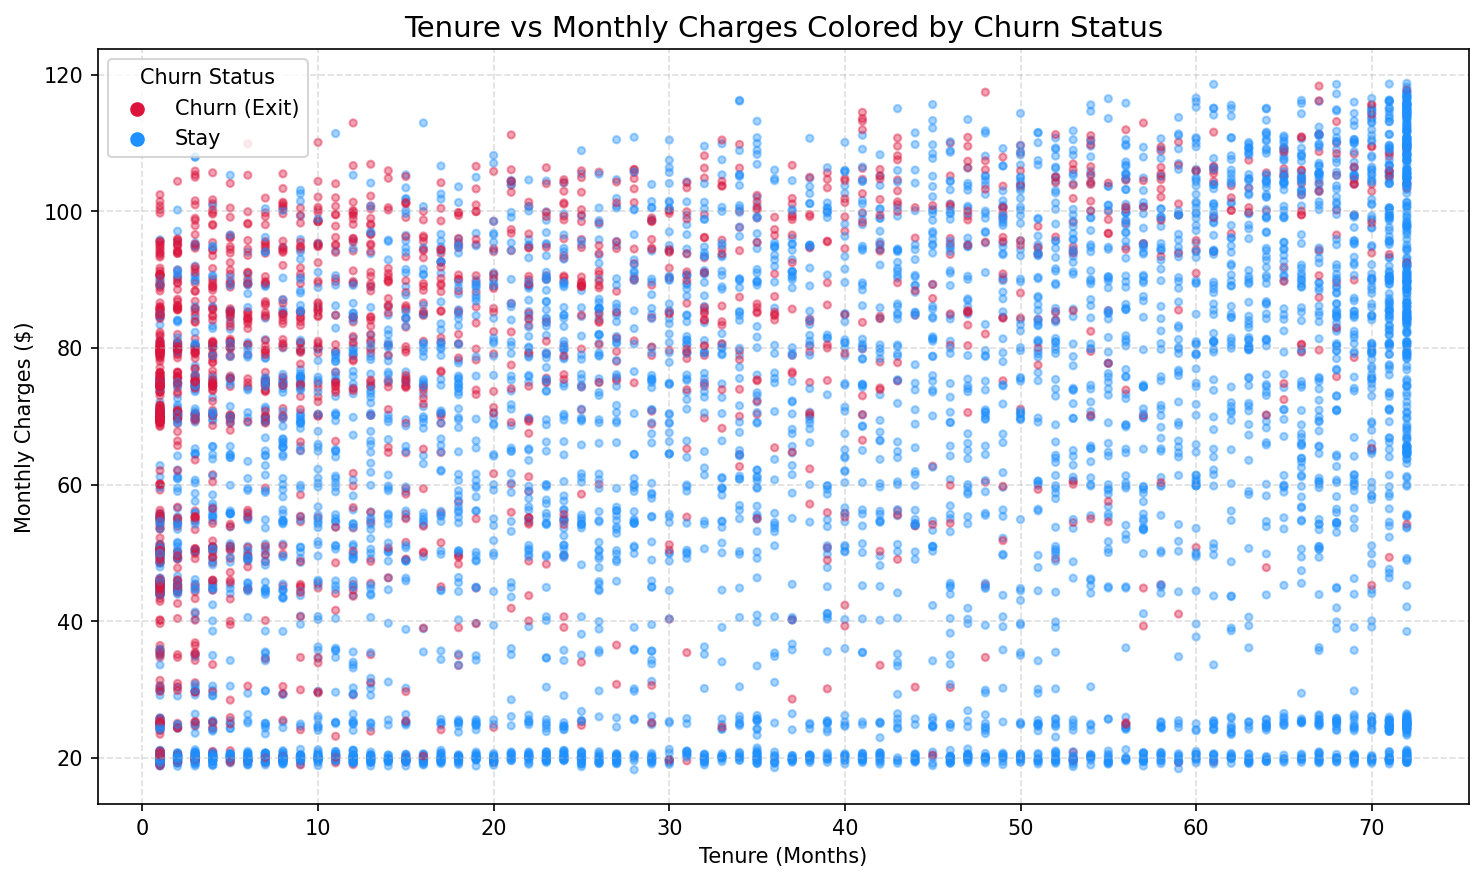

In [8]:
plt.figure(figsize=(10, 6))

# Color each point by churn status
colors = df['Churn'].map({1: 'crimson', 0: 'dodgerblue'})
plt.scatter(df['tenure'], df['MonthlyCharges'], c=colors, alpha=0.4, s=12)

# Manual legend (dummy scatter points)
plt.scatter([], [], c='crimson',    label='Churn (Exit)')
plt.scatter([], [], c='dodgerblue', label='Stay')
plt.legend(title='Churn Status', fontsize=10)

plt.title('Tenure vs Monthly Charges Colored by Churn Status', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('tenure_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print("Churn Profile:")
print("  High-Risk Zone : Tenure < 12 months  AND  Monthly Charges > $75")
print("  Low-Risk Zone  : Tenure > 36 months  (customers rarely leave after this point)")

## Section 5: Bar Chart Churn Rate by Tenure Month (Red Flag Month)
Identify the exact month where the highest percentage of customers leave.  

Red Flag Month  : Month 1
Peak Churn Rate : 62.0%
Insight         : Customers who survive past Month 5 have dramatically lower churn risk.


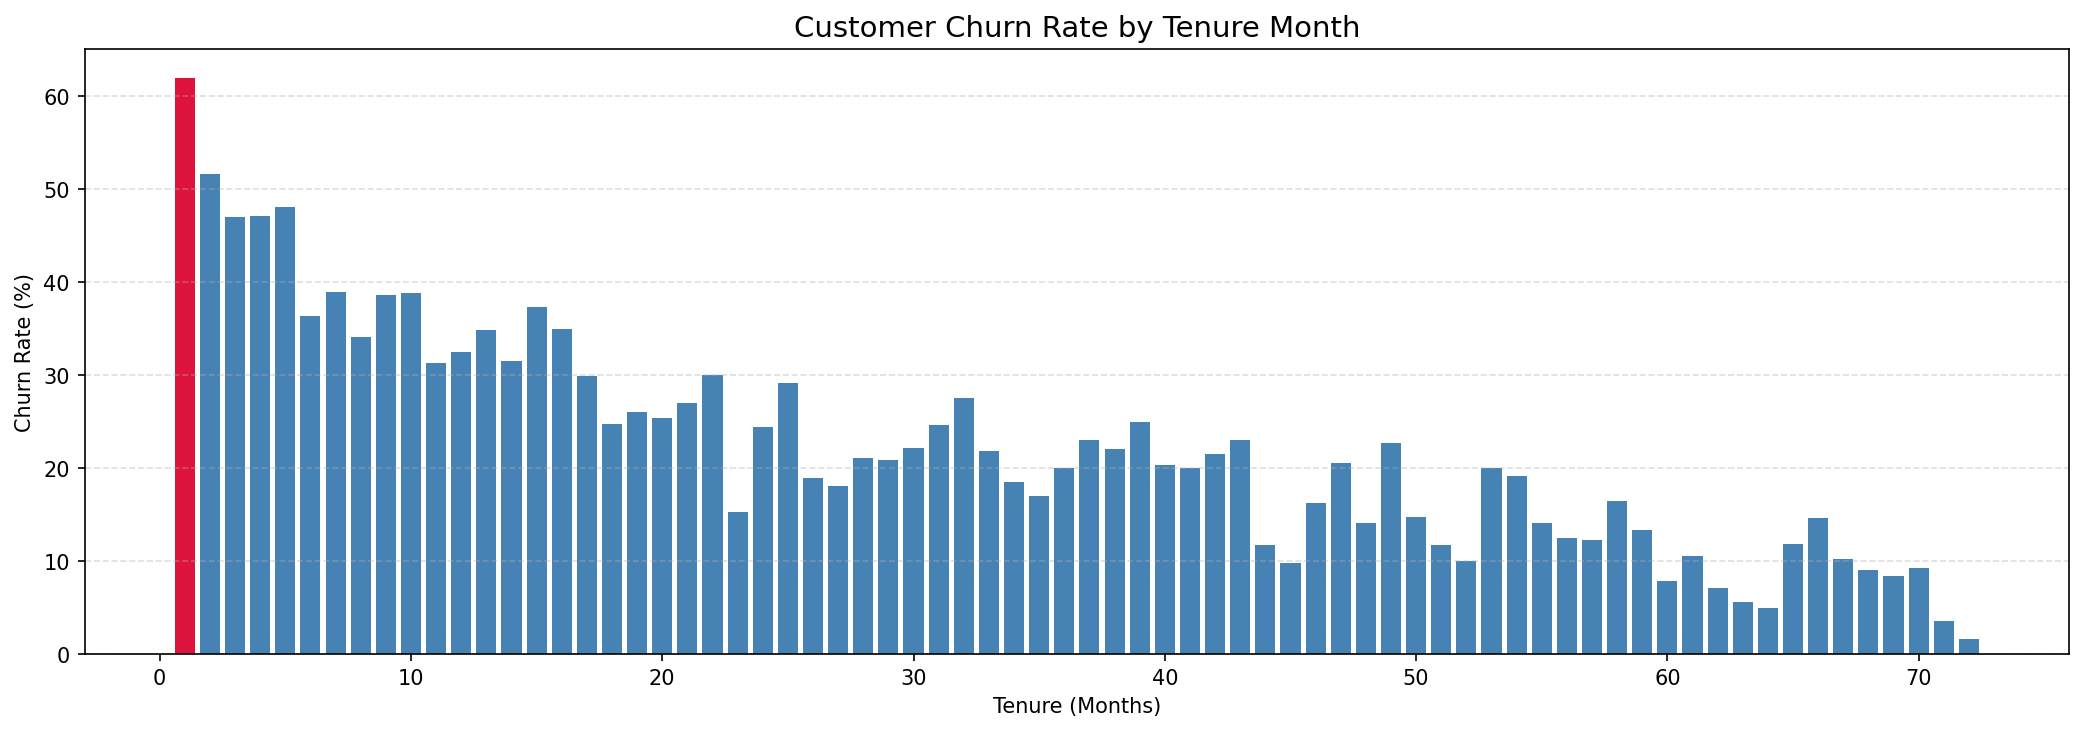

In [9]:
# Average churn rate for each tenure month (in percentage)
tenure_churn = df.groupby('tenure')['Churn'].mean() * 100

peak_month = tenure_churn.idxmax()
peak_rate  = tenure_churn.max()

# Color the peak bar red, all others steel blue
bar_colors = ['crimson' if m == peak_month else 'steelblue'
              for m in tenure_churn.index]

plt.figure(figsize=(14, 5))
plt.bar(tenure_churn.index, tenure_churn.values, color=bar_colors, edgecolor='none', width=0.8)

plt.title('Customer Churn Rate by Tenure Month', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('red_flag_month_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Red Flag Month  : Month {peak_month}")
print(f"Peak Churn Rate : {peak_rate:.1f}%")
print("Insight         : Customers who survive past Month 5 have dramatically lower churn risk.")

## Section 6: Prepare Features & Train-Test Split

We select the three features specified by the project requirements and split the data "80% training and 20% testing".  
The model trains on the training set and is evaluated on the test set data it has never seen.

In [10]:
features = ['tenure', 'MonthlyCharges', 'contract_risk']

X = df[features]   # Features (input)
y = df['Churn']    # Target  (output)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Testing  set : {X_test.shape[0]} rows")
print()
print("Features used:", features)

Training set : 5625 rows
Testing  set : 1407 rows

Features used: ['tenure', 'MonthlyCharges', 'contract_risk']


## Section 7: Scale Features

In [11]:
scaler = StandardScaler()

# Fit on training data ONLY, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # only transform never fit on test!

print("Scaling complete.")
print("Training mean (should be ~0 after scaling):", X_train_scaled.mean(axis=0).round(3))

Scaling complete.
Training mean (should be ~0 after scaling): [-0. -0.  0.]


## Section 8: Train Logistic Regression Model

In [12]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")
print(f"Evaluated on {len(y_test)} test samples.")

Logistic Regression model trained successfully.
Evaluated on 1407 test samples.


## Section 9: Evaluate the Model

We calculate all four classification metrics:

"Accuracy"
 "Precision"
 "Recall"
 "F1-Score"

In [13]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("=" * 42)
print("       Model Performance Summary")
print("=" * 42)
print(f"  Accuracy  :  {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision :  {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    :  {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score  :  {f1:.4f}  ({f1*100:.2f}%)")

       Model Performance Summary
  Accuracy  :  0.7783  (77.83%)
  Precision :  0.6069  (60.69%)
  Recall    :  0.4706  (47.06%)
  F1-Score  :  0.5301  (53.01%)


In [14]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print()
print(f"                   Predicted Churn   Predicted Stay")
print(f"  Actual Churn          {tp:>5}              {fn:>5}")
print(f"  Actual Stay           {fp:>5}              {tn:>5}")
print()
print(f"  True Negatives  (correctly predicted Stay)  : {tn}")
print(f"  True Positives  (correctly predicted Churn) : {tp}")
print(f"  False Positives (loyal customers flagged)   : {fp}") # false alarm
print(f"  False Negatives (churners we missed)        : {fn}") # most costly mistake

Confusion Matrix:

                   Predicted Churn   Predicted Stay
  Actual Churn            176                198
  Actual Stay             114                919

  True Negatives  (correctly predicted Stay)  : 919
  True Positives  (correctly predicted Churn) : 176
  False Positives (loyal customers flagged)   : 114
  False Negatives (churners we missed)        : 198
